In [24]:
#Import packages
import pandas as pd
import numpy as np
import math
import os
from astropy.io import fits
import healpy as hp
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Normalization
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data


In [27]:
test_path = "./simulated_maps/lcdm/"
with fits.open(test_path + 'cmb_map_0.fits') as hdul:
    hdul.info()
    if len(hdul) > 1 and hasattr(hdul[1], 'columns'):
        print(hdul[1].columns)
        
    #Access binary table in the first extension (index 1)
    table_data = hdul[1].data['T']

    #Flatten data to get 1D array
    map_data = np.concatenate(table_data)

Filename: ./simulated_maps/lcdm/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


NSIDE: 1024


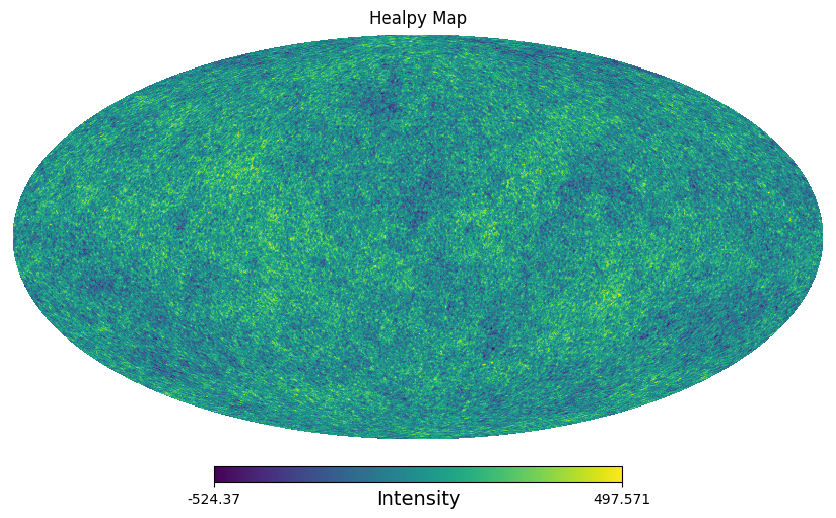

In [28]:
#Visualize the map
nside = hp.npix2nside(len(map_data))
print(f"NSIDE: {nside}")

#Plogt
hp.mollview(map_data, title="Healpy Map", unit="Intensity")
plt.show()

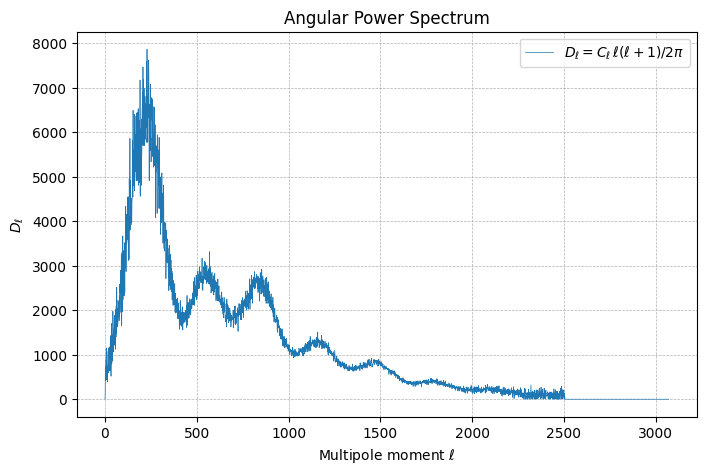

In [29]:
# Compute the angular power spectrum Cl's
cls = hp.anafast(map_data)

# Plot the power spectrum
ell = np.arange(len(cls))  # Multipole moments

plt.figure(figsize=(8, 5))
plt.plot(ell, cls * ell * (ell + 1) / (2 * np.pi), label='$D_\ell = C_\ell \, \ell(\ell+1)/2\pi$', linewidth=0.5)
plt.xlabel(r'Multipole moment $\ell$')
plt.ylabel(r'$D_\ell$')
plt.title('Angular Power Spectrum')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [ ]:
#Read the cmb TT angular power spectrum
data_Planck = np.loadtxt('./experimental_data/simulated_ang_power_spectra/lcdm/.csv', delimiter=',')

FileNotFoundError: ./experimental_data/simulated_ang_power_spectra.csv not found.

In [ ]:
#Subtract the differences (what info lost from teh process: cmb map → Cls)
